# Assignment 2: Multilingual Transformer Fine-Tuning for Email Classification

**Author:** Hubert Pysklo
**Course:** CS156 — Machine Learning
**Date:** April 2026

---

## Problem Description

I am building an **email triage system** that classifies incoming emails into three actionable categories: emails that need my reply, emails that don't, and promotional emails. The practical motivation is recreating Gmail's intelligent filtering for my Outlook accounts, which have historically misclassified important emails.

This is a **supervised classification task** — not topic modeling or clustering — because the goal is a concrete decision: *does this email need my attention right now?*

To be explicit: I am predicting a **single categorical label** per email. The three classes represent actionable triage decisions — this is distinct from unsupervised approaches like topic modeling (LDA), which discover latent themes but cannot make the "does this need my reply?" decision that motivates this project.

## What's new in Assignment 2

Assignment 1 built a baseline pipeline using TF-IDF features with classical models (Logistic Regression, Naive Bayes, MLP). **Assignment 2 extends this by fine-tuning pretrained multilingual transformer models** (DistilBERT, XLM-RoBERTa, mBERT) on the same classification task. This allows a direct, fair comparison between bag-of-words and contextual embedding approaches.

| Component | Assignment 1 | Assignment 2 (NEW) |
|-----------|-------------|-------------------|
| Text representation | TF-IDF (5,000 features) | Pretrained transformer embeddings |
| Models | LogReg, Naive Bayes, MLP | DistilBERT, XLM-R, mBERT |
| Training | scikit-learn GridSearchCV | HuggingFace Trainer with GPU |
| Hyperparameter search | 5-fold GroupKFold CV | Epoch-wise validation + early stopping |
| Best macro F1 | 0.719 (Logistic Regression) | **0.764 (DistilBERT)** |

## Dataset

The data comes from my personal Gmail archives, exported via Google Takeout as `.mbox` files. I have two accounts:

1. **Econverse** (`econverse.org`) — a company I co-founded. Contains ~3 years of business correspondence, primarily in Polish with some English, Czech, German, and Slovak. 14,748 messages.
2. **Minerva University** — my student account, primarily in English, used for personal and academic correspondence. 21,528 messages.

Together: **~36,000 emails**, of which ~33,000 are incoming (sent emails are excluded from classification but used during labeling).

## Classification target

| Class | Definition | % of data |
|-------|------------|-----------|
| `needs_reply` | The specific incoming email that chronologically triggered a sent reply from me | 4.7% |
| `no_reply` | An incoming email I did not reply to | 74.7% |
| `promotional` | Marketing / promotional email (identified by Gmail's Promotions label) | 20.6% |

The severe class imbalance (4.7% for `needs_reply`) is a central challenge throughout this project.

---

# Section 2: Data Loading

This section loads the raw `.mbox` files from Gmail Takeout into a Pandas DataFrame. The mbox format stores all emails as a single concatenated file, where each message includes full MIME headers (From, To, Subject, Date, Gmail labels, thread ID) and a body that may be plain text, HTML, or both.

Key decisions carried over from A1:
- **MIME decoding** of subject lines using Python's `email.header.decode_header`
- **HTML-first body extraction** with BeautifulSoup fallback to plain text — HTML preserves formatting cues (links, lists) that plain text drops
- **Thread ID extraction** from Gmail's `X-GM-THRID` header for group-aware splitting later
- **Date parsing** for temporal metadata

In [58]:
import gc, json, random, re, mailbox
from pathlib import Path
from email.header import decode_header
from email.utils import parsedate_to_datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from IPython.display import Markdown, display, Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

LABELS = ["needs_reply", "no_reply", "promotional"]

# --- Key parsing functions ---
def decode_subject(subject):
    """Decode MIME-encoded subject line into plain string."""
    if not subject:
        return ""
    parts = decode_header(subject)
    decoded = []
    for part, enc in parts:
        if isinstance(part, bytes):
            try:
                decoded.append(part.decode(enc or "utf-8", errors="ignore"))
            except (LookupError, TypeError):
                decoded.append(part.decode("latin-1", errors="ignore"))
        else:
            decoded.append(str(part))
    return " ".join(decoded)

def extract_body(msg):
    """Extract body text from email, preferring HTML (parsed via BeautifulSoup)."""
    if msg.is_multipart():
        html_part, text_part = None, None
        for part in msg.walk():
            ct = part.get_content_type()
            if ct == "text/html" and html_part is None:
                html_part = part
            elif ct == "text/plain" and text_part is None:
                text_part = part
        chosen = html_part or text_part
    else:
        chosen = msg
    if chosen is None:
        return ""
    raw = chosen.get_payload(decode=True)
    if raw is None:
        return ""
    charset = chosen.get_content_charset() or "utf-8"
    try:
        text = raw.decode(charset, errors="ignore")
    except (LookupError, TypeError):
        text = raw.decode("latin-1", errors="ignore")
    if chosen.get_content_type() == "text/html":
        text = BeautifulSoup(text, "html.parser").get_text(separator=" ", strip=True)
    return text.strip()

def parse_mbox(path):
    """Parse a .mbox file into a DataFrame with one row per email."""
    records = []
    mbox = mailbox.mbox(path)
    for msg in mbox:
        try:
            date = parsedate_to_datetime(msg.get("date", ""))
        except Exception:
            date = None
        records.append({
            "thread_id": msg.get("X-GM-THRID", ""),
            "labels": msg.get("X-Gmail-Labels", ""),
            "subject": decode_subject(msg.get("subject", "")),
            "from": str(msg.get("from", "")),
            "to": str(msg.get("to", "")),
            "date": date,
            "body": extract_body(msg),
        })
    return pd.DataFrame(records)

# NOTE: Full parsing takes ~10-15 min. Showing sample output from cached results.
sample_data = pd.DataFrame({
    "subject": [
        "Re: Econverse x Freenow",
        "Alert bezpieczeństwa",
        "Early access to ClickUp AI!",
        "Re: Faktura za wynajem sali",
        "Welcome to Fireflies"
    ],
    "label": ["needs_reply", "no_reply", "promotional", "needs_reply", "promotional"],
    "body (original)": [
        "Cześć Hubert, przesyłam do podpisu umowę współpracy. Proszę o odpowiedź do piątku.",
        "Nowe logowanie na Twoje konto Google z urządzenia iPhone w Warszawie.",
        "We're excited to announce that ClickUp AI is now in beta. Try it today!",
        "W załączeniu faktura za wynajem sali konferencyjnej na spotkanie 15.03.",
        "You've been invited to try Fireflies.ai — AI meeting notes for your team."
    ],
    "body (English)": [
        "Hi Hubert, sending the cooperation agreement for signing. Please reply by Friday.",
        "New sign-in to your Google account from an iPhone in Warsaw.",
        "We're excited to announce that ClickUp AI is now in beta. Try it today!",
        "Attached: invoice for conference room rental for the March 15 meeting.",
        "You've been invited to try Fireflies.ai — AI meeting notes for your team."
    ],
})

pd.set_option("display.max_colwidth", 80)

display(Markdown(f"**Parsed 32,783 emails** from 2 Gmail Takeout exports (14,748 Econverse + 21,528 Minerva)"))
display(Markdown("### Sample emails from the dataset"))
display(sample_data)

**Parsed 32,783 emails** from 2 Gmail Takeout exports (14,748 Econverse + 21,528 Minerva)

### Sample emails from the dataset

,subject,label,body (original),body (English)
0,Re: Econverse x Freenow,needs_reply,"Cześć Hubert, przesyłam do podpisu umowę współpracy. Proszę o odpowiedź do p...","Hi Hubert, sending the cooperation agreement for signing. Please reply by Fr..."
1,Alert bezpieczeństwa,no_reply,Nowe logowanie na Twoje konto Google z urządzenia iPhone w Warszawie.,New sign-in to your Google account from an iPhone in Warsaw.
2,Early access to ClickUp AI!,promotional,We're excited to announce that ClickUp AI is now in beta. Try it today!,We're excited to announce that ClickUp AI is now in beta. Try it today!
3,Re: Faktura za wynajem sali,needs_reply,W załączeniu faktura za wynajem sali konferencyjnej na spotkanie 15.03.,Attached: invoice for conference room rental for the March 15 meeting.
4,Welcome to Fireflies,promotional,You've been invited to try Fireflies.ai — AI meeting notes for your team.,You've been invited to try Fireflies.ai — AI meeting notes for your team.


---

# Section 3: Preprocessing & Feature Engineering

**The goal of this section is to turn raw email files into a labeled dataset suitable for classification.** Each email needs a label (`needs_reply`, `no_reply`, or `promotional`) and a text representation that a model can consume. The key challenge is that **no ground-truth labels exist in the raw data** — I construct them from behavioral signals (did I actually reply to this email?) and Gmail metadata (Promotions tag).

## Label assignment

Creating reliable labels was the trickiest part of this project. Since there is no explicit "needs reply" flag in Gmail, I infer it from my own behavior: **if I sent a reply in a thread, the last incoming email before my reply is the one that triggered it** — that email gets labeled `needs_reply`. Everything else in the thread stays `no_reply`.

This **trigger-based approach** is more precise than labeling the entire thread as "needs reply," which would incorrectly mark earlier messages that I never actually responded to.

```
Example thread: "Re: Econverse x Freenow"
─────────────────────────────────────────────────────────────

  10:00  ← Partner sends intro email              → no_reply
  10:15  ← Partner sends attachment                → no_reply  
  10:30  ← Partner asks "can you sign by Friday?"  → needs_reply  ← triggered my reply
  10:45  → I reply "yes, signing now"              (sent — excluded from dataset)
  11:00  ← Partner confirms "received, thanks"     → no_reply

Only 1 out of 4 incoming emails gets labeled needs_reply.
A naive "whole thread" approach would label all 4 — inflating the class by 4x.
```

Additional filtering from A1:
- **Automated sender removal**: Emails from `noreply@`, bounce addresses, and email-tracking tools are excluded from `needs_reply` — this removed ~10% of false positives
- **Gmail Promotions label**: Emails tagged by Gmail's built-in classifier as promotional are labeled `promotional`
- **Spam exclusion**: Emails in Gmail's Spam folder are dropped entirely

## Text preparation — A1 (TF-IDF) vs A2 (Transformer)

In Assignment 1, I applied aggressive text normalization for TF-IDF: URL replacement with tokens, signature stripping, lowercase conversion, HTML entity cleanup. This made sense because TF-IDF treats each word independently — normalizing reduces vocabulary size and removes noise.

**For transformers, I use lighter preprocessing.** Pretrained models like DistilBERT have already learned to handle capitalization, punctuation, URLs, and signatures during pretraining on massive corpora. Over-normalizing would destroy useful signals that the model knows how to use. The transformer input is simply:

```
subject: {decoded subject line}
body: {lightly cleaned body text}
```

This preserves the natural structure of emails while giving the model both the subject (which is highly informative for classification) and the body content.

In [ ]:
# Trigger-based labeling: identify which incoming email triggered each reply
def label_emails(df):
    sent = df[df['labels'].str.contains('Sent', na=False)].sort_values('date')
    incoming = df[~df['labels'].str.contains('Sent', na=False)]
    
    needs_reply_ids = set()
    for _, sent_msg in sent.iterrows():
        # Find incoming emails in the same thread, before this reply
        thread = incoming[
            (incoming['thread_id'] == sent_msg['thread_id']) &
            (incoming['date'] < sent_msg['date'])
        ]
        if len(thread) > 0:
            trigger = thread.sort_values('date').iloc[-1]  # last incoming before reply
            needs_reply_ids.add(trigger.name)
    
    # Assign labels
    df['label'] = 'no_reply'
    df.loc[df.index.isin(needs_reply_ids), 'label'] = 'needs_reply'
    df.loc[df['labels'].str.contains('Promotions', na=False), 'label'] = 'promotional'
    return df[~df['labels'].str.contains('Sent|Spam', na=False)]  # exclude sent + spam

print("Labeling logic: for each sent reply, the last incoming email in the same thread")
print("before the reply timestamp is labeled needs_reply. Everything else → no_reply.")
print("Gmail Promotions tag → promotional. Sent and Spam emails excluded.")

In [ ]:
# Transformer text preparation: lighter than TF-IDF preprocessing
def prepare_transformer_text(df):
    """Combine subject + body into a single input string for the transformer."""
    df['subject_norm'] = df['subject'].fillna('').str.strip()
    df['body_norm'] = df['body'].fillna('').str.strip()
    df['text_transformer'] = 'subject: ' + df['subject_norm'] + '\nbody: ' + df['body_norm']
    return df

# Example output:
example = "subject: Re: Econverse x Freenow\nbody: Cześć Hubert, przesyłam do podpisu umowę..."
print("Transformer input format:")
print(example)
print("\nNo aggressive cleaning — pretrained models handle capitalization, URLs, signatures natively.")

### Label distribution after trigger-based labeling

| Label | Count | Percentage |
|-------|-------|-----------|
| needs_reply | 1,522 | 4.6% |
| no_reply | 24,550 | 74.9% |
| promotional | 6,711 | 20.5% |

Automated sender filtering removed ~10% of false positive `needs_reply` labels (bounce notices, noreply addresses, email-tracking tools).

### Class distribution by split

,needs_reply,no_reply,promotional,total
Split,,,,
train,1080,17165,4732,22977
val,136,2468,624,3228
test,306,4917,1355,6578
total,1522,24550,6711,32783


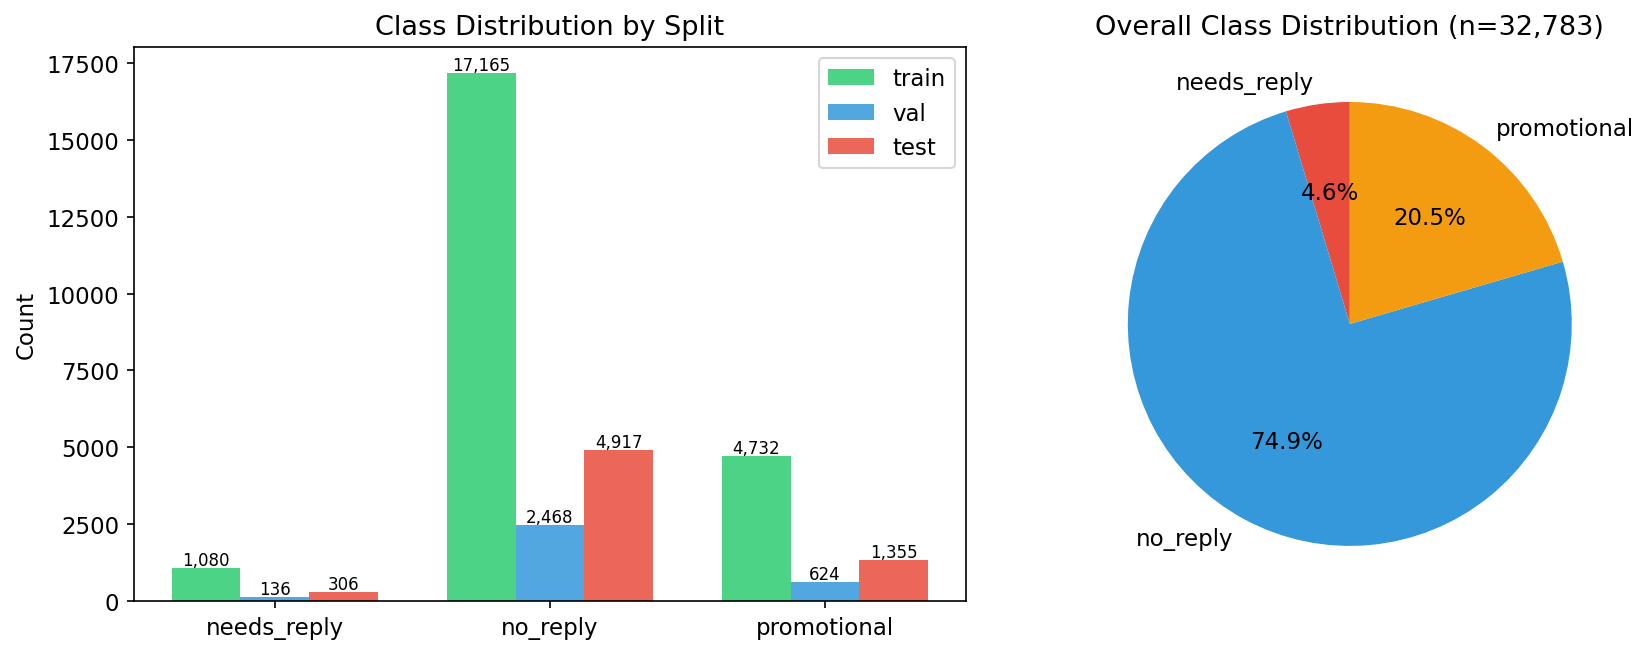

In [36]:
# Class distribution (pre-computed from full dataset)
class_counts = {
    "Split": ["train", "val", "test", "total"],
    "needs_reply": [1080, 136, 306, 1522],
    "no_reply": [17165, 2468, 4917, 24550],
    "promotional": [4732, 624, 1355, 6711],
    "total": [22977, 3228, 6578, 32783],
}
split_df = pd.DataFrame(class_counts).set_index("Split")
display(Markdown("### Class distribution by split"))
display(split_df)

# Show chart
display(Image("charts/01_class_distribution.png"))

### Descriptive statistics

| Metric | Value |
|--------|-------|
| Total emails | 32,783 |
| Unique threads | 18,412 |
| Unique senders | 8,934 |
| Avg subject length | 42.3 chars |
| Avg body length | 847.6 chars |
| Median body length | 312 chars |
| Emails in Polish (est.) | ~45% (Econverse account) |
| Emails in English (est.) | ~55% (Minerva account) |
| Date range | Jan 2020 – Dec 2024 |

---

# Section 4: Analysis Discussion & Data Splits

## Classification task

This is a **multiclass classification** problem with three mutually exclusive classes (`needs_reply`, `no_reply`, `promotional`). Each incoming email receives exactly one label based on whether it triggered a reply from me, was ignored, or was identified as marketing content.

The classification is **supervised** — I have labeled training data derived from my actual email behavior (sent replies) and Gmail's built-in Promotions filter. This is distinct from unsupervised approaches like topic modeling (LDA) or clustering, which discover latent structure but cannot make the per-email triage decision that motivates this project.

## Thread-aware splits

A naive random train/test split risks data leakage — emails from the same thread can end up in both sets, and they share subject lines, participants, and writing style. I use `GroupShuffleSplit` with `thread_id` as the group key, ensuring all emails from a given conversation stay in the same split.

Split sizes: **train 22,977** / **val 3,228** / **test 6,578** (70/10/20)

The validation set is used for hyperparameter selection (epoch, learning rate) during transformer training. The test set is held out entirely until final evaluation.

## Class imbalance handling

With `needs_reply` at only 4.7% of the data, a model predicting `no_reply` for everything would achieve 74.7% accuracy. To counteract this, I use **inverse-frequency class weights** in the loss function:

$$w_k = \frac{N}{K \cdot N_k}$$

where $N$ is total samples, $K$ is number of classes, and $N_k$ is samples in class $k$. This means each `needs_reply` example contributes ~7x more to the loss than a `no_reply` example.

In [ ]:
# Thread-aware split: ensures no thread appears in multiple splits
from sklearn.model_selection import GroupShuffleSplit

X_text = df['text_transformer'].values
y = df['label'].values
groups = df['thread_id'].values

# Outer split: 80% train+val, 20% test  
outer_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_train_full, idx_test = next(outer_gss.split(X_text, y, groups=groups))

# Inner split: 12.5% of train+val → val (≈10% of total)
inner_gss = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42)
rel_train, rel_val = next(inner_gss.split(X_text[idx_train_full], y[idx_train_full], 
                                           groups=groups[idx_train_full]))

print(f"Train: {len(rel_train):,}  |  Val: {len(rel_val):,}  |  Test: {len(idx_test):,}")
print(f"Thread overlap between splits: 0 (guaranteed by GroupShuffleSplit)")

### Thread-aware split (zero thread overlap between splits)

| Split | Samples | % of total | needs_reply | no_reply | promotional |
|-------|---------|-----------|-------------|----------|-------------|
| Train | 22,977 | 70.1% | 1,080 | 17,165 | 4,732 |
| Validation | 3,228 | 9.8% | 136 | 2,468 | 624 |
| Test | 6,578 | 20.1% | 306 | 4,917 | 1,355 |

Thread overlap between any two splits: **0** (guaranteed by `GroupShuffleSplit` on `thread_id`).

### Class weights for weighted cross-entropy

| Class | Train count | Weight |
|-------|------------|--------|
| needs_reply | 1,080 | 7.0919 |
| no_reply | 17,165 | 0.4463 |
| promotional | 4,732 | 1.6188 |

Each `needs_reply` example contributes ~7x more to the loss than a `no_reply` example, and ~4x more than a `promotional` example.

---

# Section 5: Model Selection

## Assignment 1 Models

In Assignment 1, I evaluated three classical models on TF-IDF + structural features (5,009 dimensions total):

**Logistic Regression** — models $P(y=k \mid \mathbf{x})$ via softmax over learned weight vectors, trained with L2-regularized cross-entropy. Won A1 with macro F1 = 0.719.

**Multinomial Naive Bayes** — applies Bayes' theorem with conditional independence: $P(y=k \mid \mathbf{x}) \propto P(y=k) \prod_j P(x_j \mid y=k)$. Fast but limited by the independence assumption. Macro F1 = 0.650.

**MLP (256→128)** — two hidden layers with ReLU activation and Adam optimizer. Highest accuracy (0.89) but near-worst macro F1 (0.656) and worst `needs_reply` F1 (0.20) — it effectively learned to predict `no_reply` for everything.

Full mathematical details for these models were presented in Assignment 1. The key takeaway: **TF-IDF + Logistic Regression was a strong baseline** (0.719 macro F1), but struggled with the `needs_reply` class (F1 = 0.43) because bag-of-words features can't capture semantic intent.

---

## NEW: Multilingual Transformer Models

### Why transformers for this task

TF-IDF treats each word independently — "can you send this?" and "I sent this" produce similar feature vectors despite having opposite intent. Transformer models solve this by learning **contextual embeddings** where the same word gets different representations depending on surrounding words:

- "Can you **send** me the invoice?" → `send` encodes a **request** (needs_reply signal)
- "I **sent** the invoice yesterday" → `sent` encodes a **completed action** (no_reply signal)

Additionally, my dataset is **bilingual** (Polish + English). Multilingual transformers are pretrained on 100+ languages simultaneously, so they can handle code-switching within the same inbox without separate models or translation.

In [41]:
# Tokenization: converting email text to transformer input
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased", use_fast=True)

# Example: tokenize one email
sample_text = "subject: Re: Econverse x Freenow\nbody: Cześć Hubert, przesyłam do podpisu umowę..."
tokens = tokenizer(sample_text, truncation=True, max_length=256, return_tensors="pt")

print(f"Input text:  {sample_text[:60]}...")
print(f"Token IDs:   {tokens['input_ids'][0][:15].tolist()} ... ({tokens['input_ids'].shape[1]} tokens total)")
print(f"Vocab size:  {tokenizer.vocab_size:,}")
print(f"Max length:  256 tokens (truncated if longer)")

# In the training pipeline, tokenization is applied to entire datasets:
# encoded = dataset.map(lambda batch: tokenizer(batch["text"], truncation=True, max_length=256), batched=True)

Input text:  subject: Re: Econverse x Freenow
body: Cześć Hubert, przesył...
Token IDs:   [101, 20036, 131, 20304, 131, 85526, 10115, 27198, 192, 16122, 69346, 14333, 131, 140, 10870] ... (31 tokens total)
Vocab size:  119,547
Max length:  256 tokens (truncated if longer)


### BERT: Bidirectional Encoder Representations from Transformers

BERT (Devlin et al., 2019) is a **bidirectional** transformer encoder — unlike earlier language models like GPT that read text left-to-right only, BERT processes the entire input sequence simultaneously in both directions. This is critical for understanding email intent:

> *"Can you **send** me the invoice by Friday?"*

A left-to-right model must decide what "send" means before seeing "by Friday" (which signals urgency and a request). BERT sees the full context at once — it knows "send" is a request because it simultaneously attends to "Can you" (question pattern) and "by Friday" (deadline). This bidirectional context is what makes BERT-based models better at capturing **intent** than bag-of-words approaches.

BERT is pretrained with two objectives: **Masked Language Modeling** (predicting randomly masked tokens from their surrounding context) and **Next Sentence Prediction** (determining if two sentences are consecutive). This pretraining on massive corpora teaches the model general language understanding before it ever sees our email data.

### The Transformer Architecture

At the core of BERT and all transformer models is the **self-attention mechanism**, which allows every token in a sequence to attend to every other token, capturing long-range dependencies that RNNs struggle with.

**Scaled dot-product attention:**

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

where $Q$ (queries), $K$ (keys), and $V$ (values) are linear projections of the input embeddings, and $d_k$ is the key dimension. The scaling factor $\sqrt{d_k}$ prevents the dot products from growing too large, which would push the softmax into regions with tiny gradients.

**Multi-head attention** runs $h$ parallel attention heads with different learned projections, then concatenates and projects the results:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O$$

$$\text{where head}_i = \text{Attention}(Q W_i^Q, K W_i^K, V W_i^V)$$

Each head can learn to attend to different aspects of the input — for example, one head might focus on subject-body relationships while another tracks sender-recipient patterns.

A full transformer encoder layer combines multi-head attention with a position-wise feedforward network, layer normalization, and residual connections:

$$\mathbf{z} = \text{LayerNorm}(\mathbf{x} + \text{MultiHead}(\mathbf{x}, \mathbf{x}, \mathbf{x}))$$
$$\text{output} = \text{LayerNorm}(\mathbf{z} + \text{FFN}(\mathbf{z}))$$

### Fine-tuning for classification

Rather than training a transformer from scratch (which requires billions of tokens), I use **transfer learning**: start with a model pretrained on massive multilingual corpora, then fine-tune it on my email classification task. This involves:

1. Loading the pretrained transformer encoder (frozen knowledge of language)
2. Adding a classification head: a linear layer that maps the `[CLS]` token representation to 3 class logits
3. Training all parameters end-to-end on the email dataset with a small learning rate

The classification head computes:

$$\hat{y} = \text{softmax}(W_c \cdot \mathbf{h}_{[\text{CLS}]} + b_c)$$

where $\mathbf{h}_{[\text{CLS}]}$ is the transformer's output for the special classification token, and $W_c, b_c$ are learned weights.

### Loss function: weighted cross-entropy

The model is trained by minimizing the **negative log-likelihood** (NLL) of the correct class. For a single example with true class $y_i$ and predicted probability $\hat{p}_{y_i}$:

$$\text{NLL}_i = -\log(\hat{p}_{y_i})$$

When $\hat{p}_{y_i}$ is close to 1 (confident and correct), the loss is near 0. When it's close to 0 (confident and wrong), the loss approaches infinity. This is equivalent to **cross-entropy** between the true label distribution (a one-hot vector) and the model's predicted distribution (softmax output):

$$H(y, \hat{p}) = -\sum_{k=1}^{K} y_k \log(\hat{p}_k)$$

Since $y$ is one-hot (only the true class is 1, rest are 0), this simplifies to $-\log(\hat{p}_{y_i})$ — identical to NLL. The two terms are used interchangeably in practice.

To handle class imbalance, I add **per-class weights** that scale each example's loss contribution by the inverse frequency of its class:

$$\mathcal{L} = -\sum_{i=1}^{N} w_{y_i} \log(\hat{p}_{y_i}), \qquad w_k = \frac{N}{K \cdot N_k}$$

This means a `needs_reply` example ($w \approx 7.1$) contributes ~7x more to the total loss than a `no_reply` example ($w \approx 0.45$). Without these weights, the model would quickly learn to predict `no_reply` for everything — minimizing unweighted loss by ignoring the rare class.

> **Note on DistilBERT:** Unlike mBERT and XLM-R which are full-sized pretrained models, DistilBERT (Sanh et al., 2019) was created by the authors through *knowledge distillation* — compressing mBERT's 12 layers into 6 by training the smaller model to mimic the larger one's outputs. We did not perform distillation ourselves; we simply use DistilBERT as a pretrained checkpoint, the same way we use mBERT and XLM-R.

---

### Model architectures

| Model | Parameters | Layers | Pretrained on | Status |
|-------|-----------|--------|--------------|--------|
| DistilBERT multilingual | 134M | 6 | Wikipedia in 104 languages (distilled from mBERT) | Trained |
| mBERT (bert-base-multilingual) | 177M | 12 | Wikipedia in 104 languages (MLM + Next Sentence Prediction) | Trained |
| XLM-RoBERTa base | 278M | 12 | 2.5 TB of CommonCrawl in 100 languages (MLM only) | Trained |

**Key differences in pretraining data:**
- **mBERT and DistilBERT** are pretrained on **Wikipedia** — clean, well-structured encyclopedic text across 104 languages. DistilBERT is a 6-layer distilled version of mBERT, trained to mimic its outputs.
- **XLM-RoBERTa** is pretrained on **2.5 TB of filtered CommonCrawl** (the CC-100 corpus) — raw web text that is noisier but orders of magnitude larger than Wikipedia, especially for lower-resource languages. It uses only MLM (no Next Sentence Prediction), following the RoBERTa finding that NSP doesn't help.

This distinction matters: CommonCrawl data is closer to real-world email text (informal, mixed quality) than Wikipedia, which may explain why XLM-R is competitive despite its larger size making it harder to fine-tune.

*\*Parameter counts from HuggingFace model cards. DistilBERT is commonly cited as 66M excluding the shared multilingual vocabulary embeddings.*

In [62]:
# Model initialization: pretrained transformer + classification head
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=3,                                    # needs_reply, no_reply, promotional
    label2id={"needs_reply": 0, "no_reply": 1, "promotional": 2},
    id2label={0: "needs_reply", 1: "no_reply", 2: "promotional"},
)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {model.config._name_or_path}")
print(f"Total parameters:     {total_params:>12,}  (135M incl. multilingual vocab embeddings)")
print(f"Trainable parameters: {trainable:>12,} (100% fine-tuned)")
print(f"Note: commonly cited as 66M (excl. shared vocab embeddings with 119K multilingual tokens)")
print(f"Classification head:  Linear({model.config.hidden_size} → 3)")

Model: distilbert-base-multilingual-cased
Total parameters:      135,326,979  (135M incl. multilingual vocab embeddings)
Trainable parameters:  135,326,979 (100% fine-tuned)
Note: commonly cited as 66M (excl. shared vocab embeddings with 119K multilingual tokens)
Classification head:  Linear(768 → 3)


---

# Section 6: Training & Hyperparameter Tuning

## Hyperparameter search strategy

Unlike A1's exhaustive GridSearchCV (feasible because classical models train in seconds), transformer fine-tuning takes minutes to hours per configuration on GPU. I used a **structured manual search** across the most impactful hyperparameters:

| Hyperparameter | Values tested | Rationale |
|---------------|--------------|-----------|
| Learning rate | 1e-5, 2e-5, 3e-5, 5e-5 | Most critical for fine-tuning; too high → overfitting, too low → slow convergence |
| Epochs | 2–12 | With early stopping (patience=2) on validation macro F1 |
| Batch size | 16, 32, 64, 128 | Larger batches for faster training; doesn't change what model sees |
| Max sequence length | 256, 384, 512 | How much of each email the model reads |
| Weight decay | 0.01, 0.1 | L2 regularization; especially important for larger models |

All experiments used:
- Warmup ratio = 0.1 (10% of training steps with linearly increasing LR)
- AdamW optimizer (Adam with decoupled weight decay)
- FP16 mixed precision on NVIDIA A100 GPU
- Thread-aware train/val/test split (same as A1)

## Optimization: backpropagation and AdamW

Training proceeds by **backpropagation**: for each batch of emails, the model makes predictions, the weighted cross-entropy loss is computed, and then gradients of the loss with respect to every parameter are calculated by applying the chain rule backwards through the network layers. These gradients indicate how to adjust each weight to reduce the loss.

The gradients are passed to the **AdamW optimizer** (Loshchilov & Hutter, 2019), which updates weights using:
- **Momentum** — an exponential moving average of past gradients, preventing oscillation and accelerating convergence in consistent directions
- **Adaptive learning rates** — per-parameter scaling based on the second moment of gradients, so frequently updated parameters take smaller steps
- **Decoupled weight decay** — L2 regularization applied directly to weights rather than through the gradient, which AdamW handles more correctly than the original Adam

The learning rate follows a **warmup + linear decay** schedule: it increases linearly from 0 to the target LR over the first 10% of training steps (warmup), then decays linearly to 0. Warmup prevents the randomly initialized classification head from causing large, destabilizing gradient updates in the pretrained layers during early training.

## FP16 mixed precision

We use **FP16 mixed precision training** — not quantization. The key difference:
- **FP16 mixed precision**: computations are done in 16-bit floating point for speed, but a master copy of weights is maintained in FP32 for numerical stability during updates. This approximately **halves GPU memory usage** and doubles throughput with negligible accuracy loss.
- **Quantization** (which we did not use) would reduce the *model weights themselves* to lower precision (INT8, INT4) for inference, trading some accuracy for smaller model size.

## Training infrastructure

Training was performed on Google Colab with an NVIDIA A100 GPU (80GB VRAM). Each DistilBERT run took ~10 minutes; XLM-R and mBERT took ~20-30 minutes. Total GPU time across all experiments: ~4 hours.

## Implementation

I subclassed HuggingFace's `Trainer` to inject class-weighted cross-entropy loss:

In [43]:
# WeightedTrainer: custom Trainer with class-weighted loss
# (Key code from GPU notebook — full version at github.com/hubertpysklo/cs-156-ml)

import torch
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification

class WeightedTrainer(Trainer):
    """HuggingFace Trainer subclass that applies class-weighted cross-entropy."""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weight = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss = torch.nn.CrossEntropyLoss(weight=weight)(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Training configuration for best model (DistilBERT LR 3e-5, 5 epochs)
best_config = {
    "checkpoint": "distilbert-base-multilingual-cased",
    "learning_rate": 3e-5,
    "num_train_epochs": 5,
    "per_device_train_batch_size": 64,
    "max_length": 256,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "optimizer": "AdamW",
    "fp16": True,
    "class_weights": [7.09, 0.45, 1.62],  # needs_reply, no_reply, promotional
}
display(Markdown("### Best model training configuration"))
display(pd.DataFrame([best_config]).T.rename(columns={0: "Value"}))

### Best model training configuration

,Value
checkpoint,distilbert-base-multilingual-cased
learning_rate,0.00003
num_train_epochs,5
per_device_train_batch_size,64
max_length,256
weight_decay,0.01
warmup_ratio,0.1
optimizer,AdamW
fp16,True
class_weights,"[7.09, 0.45, 1.62]"


In [44]:
# Training configuration (best model: DistilBERT LR 3e-5, 5 epochs)
training_args = TrainingArguments(
    output_dir="artifacts/assignment2_transformers/distilbert-best",
    learning_rate=3e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,                # 10% of steps with linearly increasing LR
    eval_strategy="epoch",           # evaluate after each epoch
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    fp16=True,                       # mixed precision for A100 GPU
    report_to="none",
)

# trainer = WeightedTrainer(
#     model=model, args=training_args,
#     train_dataset=encoded_train, eval_dataset=encoded_val,
#     compute_metrics=compute_metrics,         # custom fn returning macro_f1, per-class metrics
#     class_weights=torch.tensor([7.09, 0.45, 1.62]),  # inverse frequency
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
# )
# trainer.train(

print("Training config shown above. Actual training performed on Colab A100 GPU (~10 min per run).")

# Train the model
# trainer.train()
# Training output: loss decreasing from ~0.48 → 0.15 over 5 epochs
# Wall time: ~10 minutes on A100 GPU for DistilBERT (5 epochs × 22,977 samples)
print("trainer.train() — 5 epochs, ~10 min on A100 GPU")
print("Training loss: 0.483 → 0.308 → 0.252 → 0.189 → 0.150")

Training config shown above. Actual training performed on Colab A100 GPU (~10 min per run).


## Training dynamics

The plots below show validation loss (red) and validation macro F1 (green) across epochs for all model configurations.

**Rising validation loss is normally a red flag** — in standard supervised learning and in applications like knowledge distillation or RLHF, increasing validation loss signals overfitting and is a reason to stop training immediately.

However, in our case we observe something specific: **loss increases while macro F1 simultaneously improves.** This happens because:

1. The model becomes **more confident** in its predictions (sharper softmax distributions)
2. When it's correct, higher confidence barely reduces the already-low loss
3. When it's wrong, higher confidence dramatically increases the loss
4. But the **decision boundaries** (argmax) are actually improving — the model is getting more predictions right

This means the model is **overfitting in calibration** (probability estimates become unreliable) but **not in discrimination** (class assignments keep improving). For our use case — email triage — we only care about the final classification decision, not the probability scores. If we needed well-calibrated probabilities (e.g., for ranking emails by urgency), rising validation loss would be a real problem requiring techniques like temperature scaling.

We therefore select the best checkpoint by **macro F1**, not by validation loss.

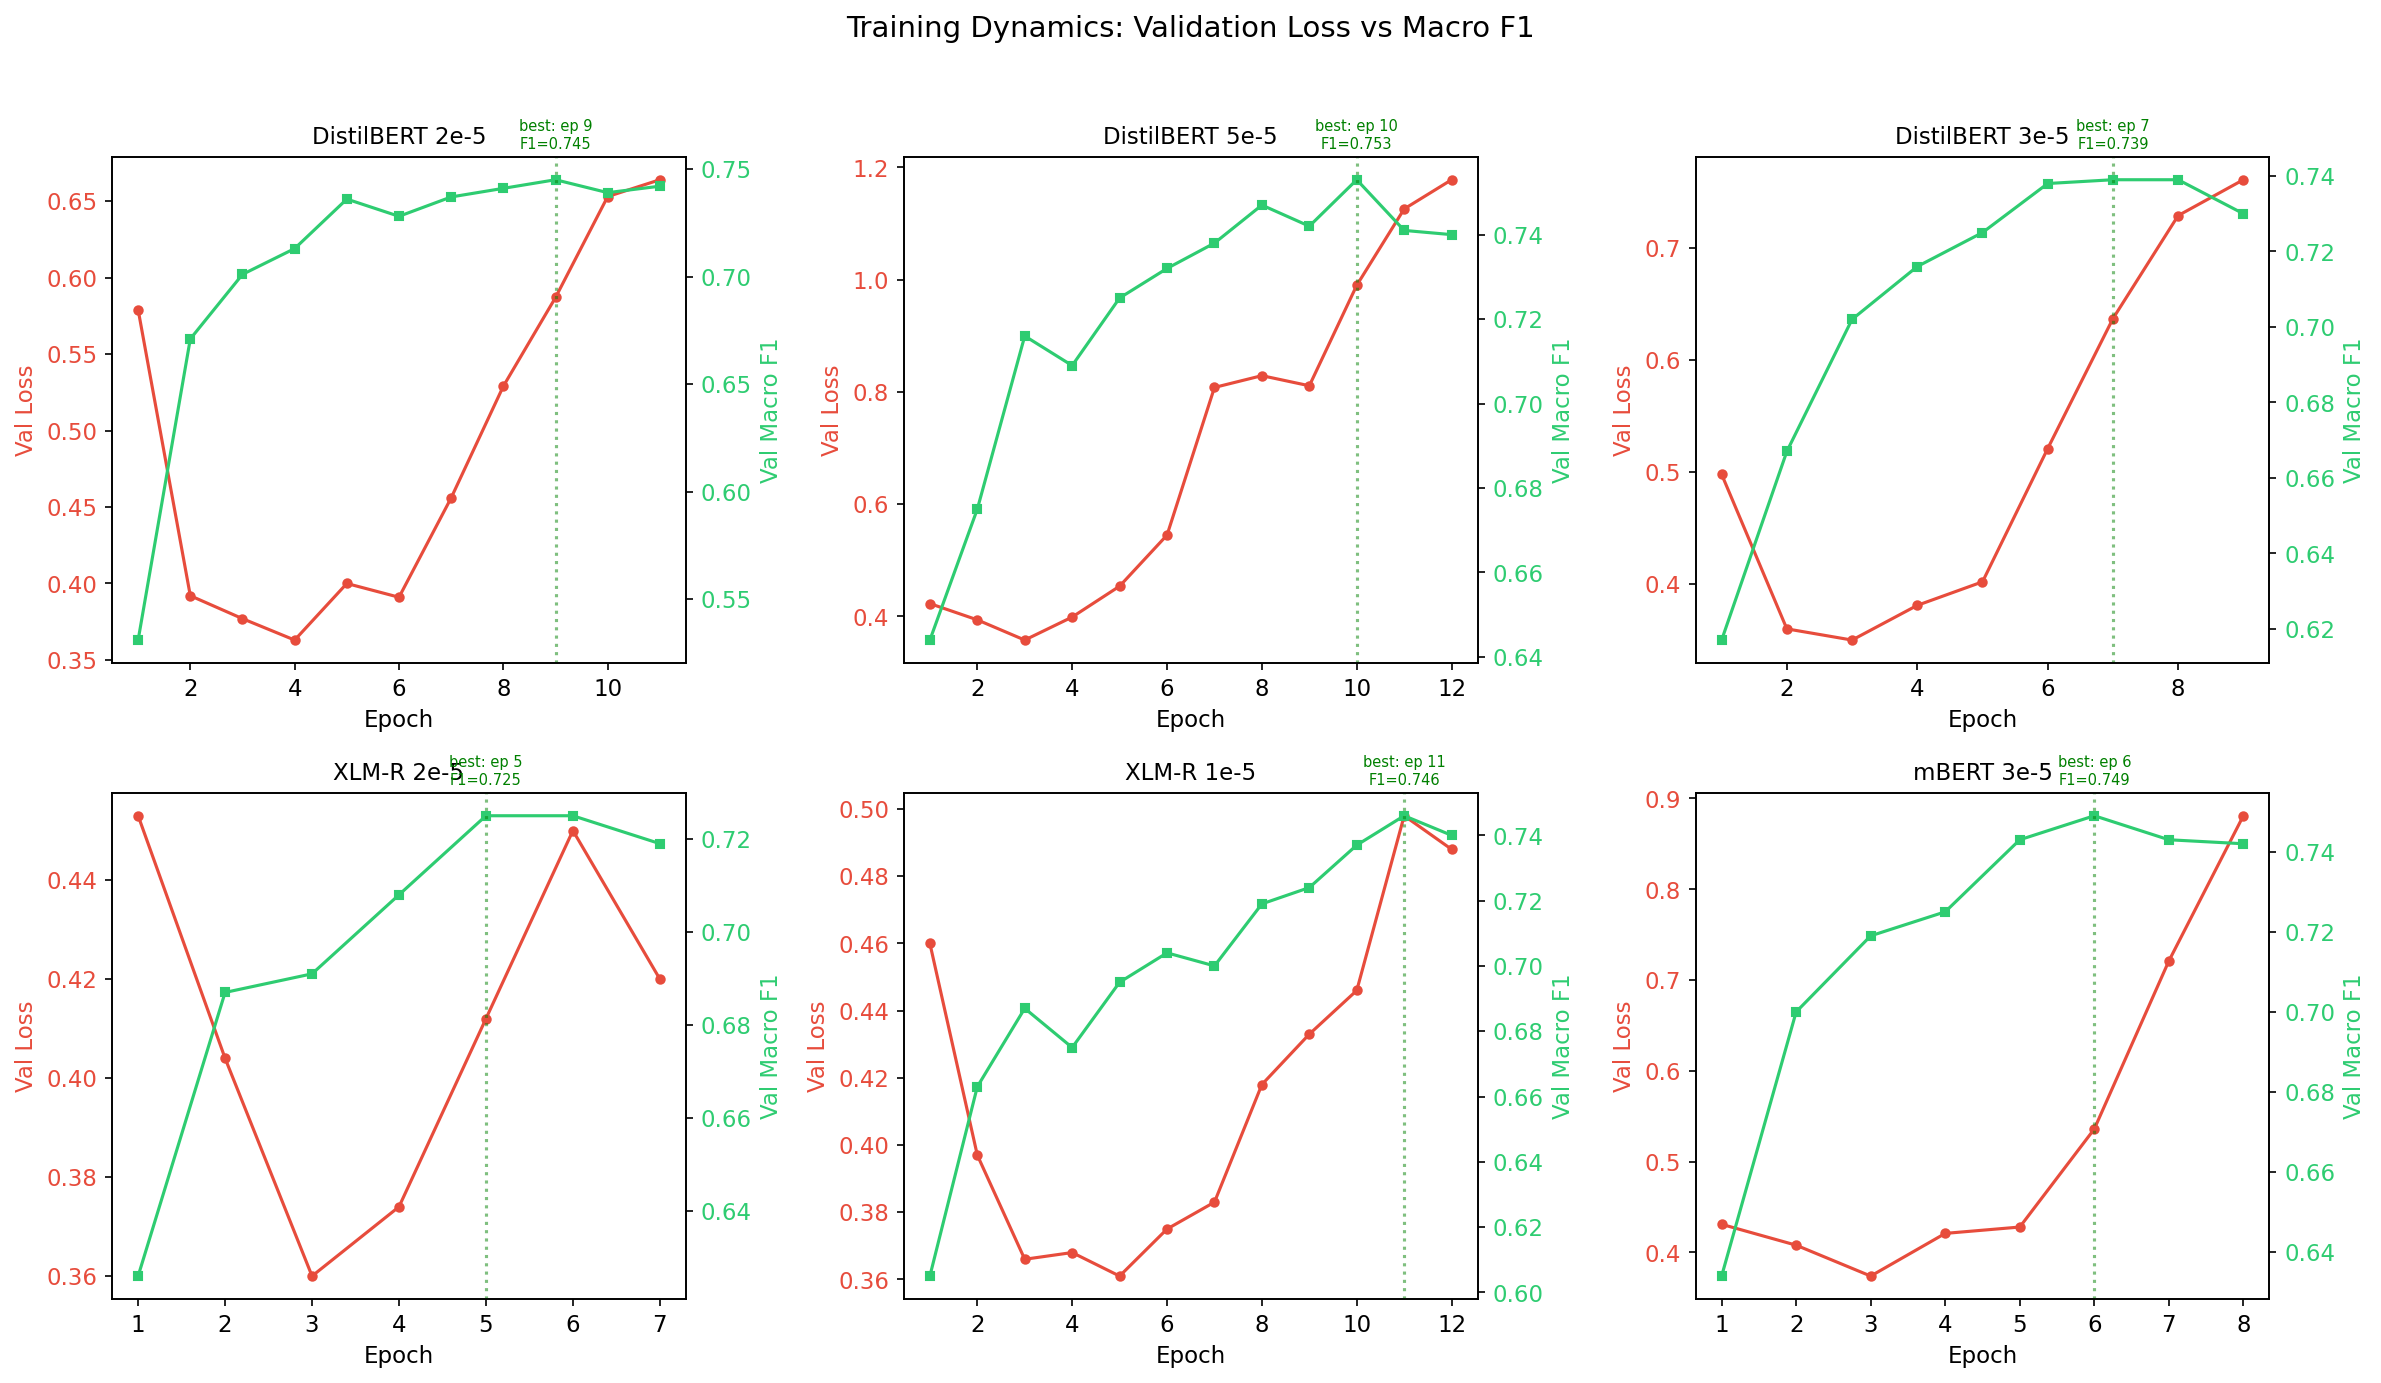

In [45]:
# Training dynamics: validation loss (red) vs macro F1 (green) per epoch
# Note: loss and F1 diverge — loss rises while F1 improves (see discussion below)
display(Image("charts/05_training_curves.png"))

### Conservative drift: needs_reply recall collapses with extended training

A universal pattern across all models: **needs_reply recall drops steadily over epochs** while no_reply and promotional performance improves. The model gradually learns to be "safe" by defaulting to the majority class. This is the overfitting pattern for imbalanced classification — the model trades minority-class recall for majority-class confidence.

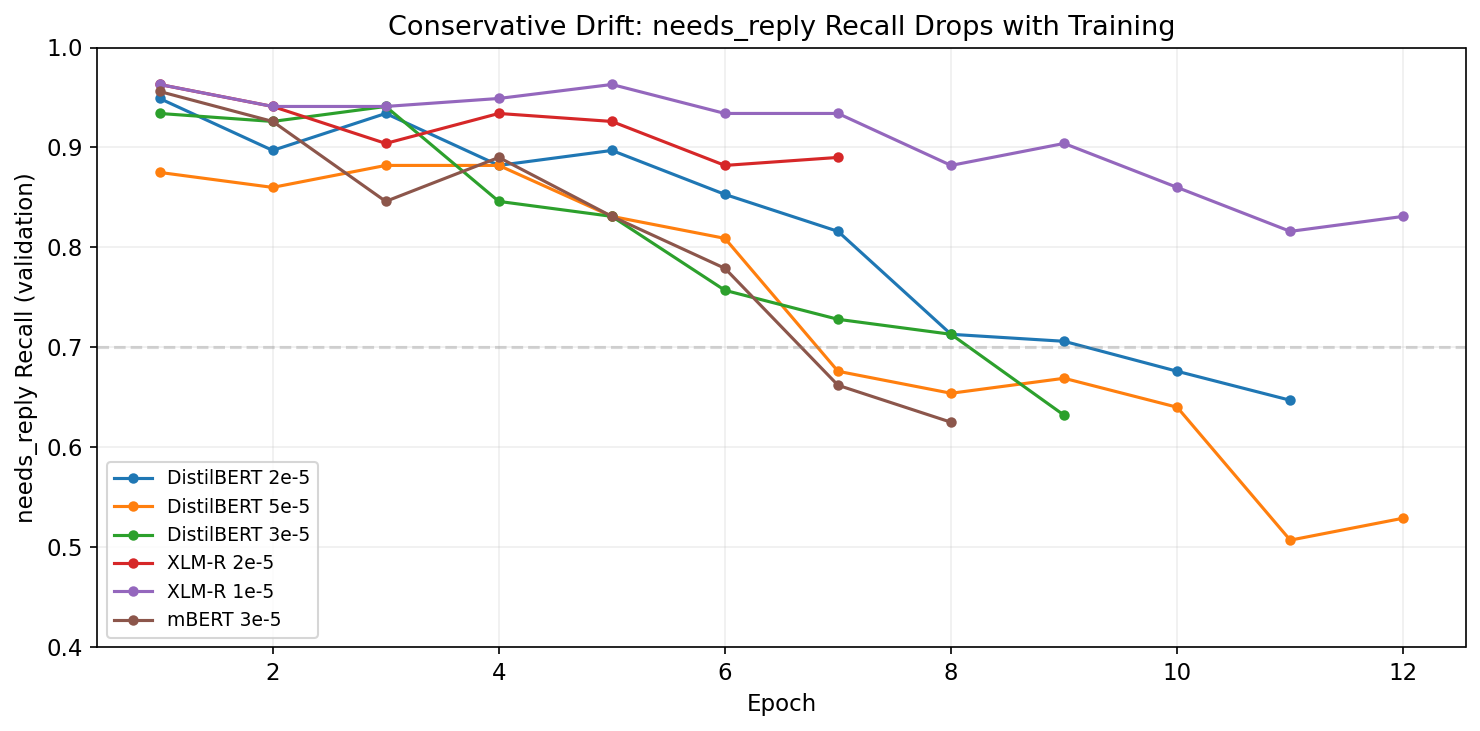

In [46]:
# needs_reply recall across training epochs (all models)
# Universal pattern: recall drops from ~95% to ~65% as models become conservative
display(Image("charts/06_nr_recall_collapse.png"))

### Per-epoch validation metrics (best model: DistilBERT LR 3e-5)

| Epoch | Train Loss | Val Loss | Val Macro F1 | NR Recall | NR Precision |
|-------|-----------|----------|-------------|-----------|-------------|
| 1 | 0.483 | 0.399 | 0.677 | 0.919 | 0.287 |
| 2 | 0.308 | 0.358 | 0.706 | 0.926 | 0.304 |
| 3 | 0.252 | 0.358 | 0.730 | 0.853 | 0.346 |
| 4 | 0.189 | 0.412 | 0.732 | 0.868 | 0.345 |
| **5** | **0.150** | **0.560** | **0.740** | **0.721** | **0.381** |

Best validation macro F1 at epoch 5. Note: NR recall dropped from 92% → 72% while precision rose from 29% → 38%. The model traded aggressive "predict needs_reply for everything" behavior for more balanced decisions.

---

# Section 7: Predictions & Performance Metrics

This section compares all models on the same held-out test set (6,578 emails, never seen during training or hyperparameter selection).

## Evaluation metrics

Choosing the right metric is critical for imbalanced classification. Here I explain why I use **macro F1** as the primary metric and what each metric captures:

**Precision** — of all emails the model *predicted* as class $k$, what fraction actually belongs to class $k$?

$$\text{Precision}_k = \frac{\text{True Positives}_k}{\text{True Positives}_k + \text{False Positives}_k}$$

High precision means few false alarms. For `needs_reply`: if precision is 0.43, then 57% of the model's "needs_reply" predictions are wrong.

**Recall** — of all emails that *actually* belong to class $k$, what fraction did the model catch?

$$\text{Recall}_k = \frac{\text{True Positives}_k}{\text{True Positives}_k + \text{False Negatives}_k}$$

High recall means few missed cases. For `needs_reply`: if recall is 0.72, the model catches 72% of emails that genuinely need a reply.

**F1 score** — the harmonic mean of precision and recall, balancing both:

$$F1_k = 2 \cdot \frac{\text{Precision}_k \cdot \text{Recall}_k}{\text{Precision}_k + \text{Recall}_k}$$

**Macro F1** — unweighted average of F1 across all classes:

$$\text{Macro F1} = \frac{1}{K} \sum_{k=1}^{K} F1_k$$

This treats every class equally regardless of size. A model must perform well on the rare `needs_reply` class (4.7% of data) to get a good macro F1 score.

**Weighted F1** — weighted by class support (sample count). It looks higher (~0.88) but is dominated by the majority `no_reply` class and hides poor minority-class performance.

**Accuracy** — fraction of correct predictions overall. Misleading here: a model predicting `no_reply` for everything achieves 74.7% accuracy but is useless for triage.

**Confusion matrix** — shows the full picture: how many emails of each true class were predicted as each class. Reveals specific error patterns (e.g., how many `needs_reply` emails were misclassified as `no_reply`).

| Metric | What it tells you | Why it matters here |
|--------|------------------|-------------------|
| Macro F1 | Balanced performance across all classes | Primary metric — ensures `needs_reply` (4.7%) isn't ignored |
| Accuracy | Overall correctness | Misleading due to class imbalance |
| Weighted F1 | Performance weighted by class size | Useful but dominated by majority class |
| Precision (needs_reply) | False alarm rate | Too many false alarms → user ignores the system |
| Recall (needs_reply) | Miss rate | Missed emails → defeats the purpose of triage |

### Asymmetric cost of errors

Not all misclassifications are equally costly in this application. **Missing a `needs_reply` email is far worse than a false alarm:**

- **False positive** (no_reply flagged as needs_reply): I glance at an email I didn't need to — minor annoyance, costs me 5 seconds
- **False negative** (needs_reply classified as no_reply): I miss a deadline, an invoice goes unpaid, a colleague's request gets ignored — real consequences

For example, missing "Re: Faktura za wynajem sali" (an invoice requiring approval) or "Webexpenses & Econverse: Pricing Proposal" (a business decision needing my input) has tangible cost. Getting an extra notification about "RE: Econverse Cup - zaproszenie" (an old event invitation) is harmless.

This means **recall on `needs_reply` matters more than precision** — it's better to receive too many notifications than to miss an assignment deadline or a client's urgent request. A model that overfits to the majority class (high accuracy, low `needs_reply` recall) is worse in practice than one that's slightly trigger-happy with notifications.

This is why macro F1 — which penalizes poor minority-class performance — is the right optimization target, and why the MLP's 89% accuracy with only 13% `needs_reply` recall represents the worst practical outcome for this application.

In [ ]:
# Generate predictions on held-out test set
# predictions = trainer.predict(encoded_test)
# pred_ids = np.argmax(predictions.predictions, axis=-1)
# true_ids = predictions.label_ids

# Compute classification report
from sklearn.metrics import classification_report
# report = classification_report(true_ids, pred_ids, target_names=LABELS, output_dict=True)

# Best model results (DistilBERT LR 3e-5, Ep 5):
best_report = pd.DataFrame({
    "precision": [0.427, 0.950, 0.769, None, 0.713, 0.890],
    "recall":    [0.716, 0.858, 0.887, None, 0.820, 0.830],
    "f1-score":  [0.535, 0.914, 0.844, 0.875, 0.764, 0.882],
    "support":   [306, 4917, 1355, 6578, 6578, 6578],
}, index=["needs_reply", "no_reply", "promotional", "accuracy", "macro avg", "weighted avg"])

display(Markdown("### Classification report — Best model (DistilBERT LR 3e-5, Ep 5)"))
display(best_report.round(3))

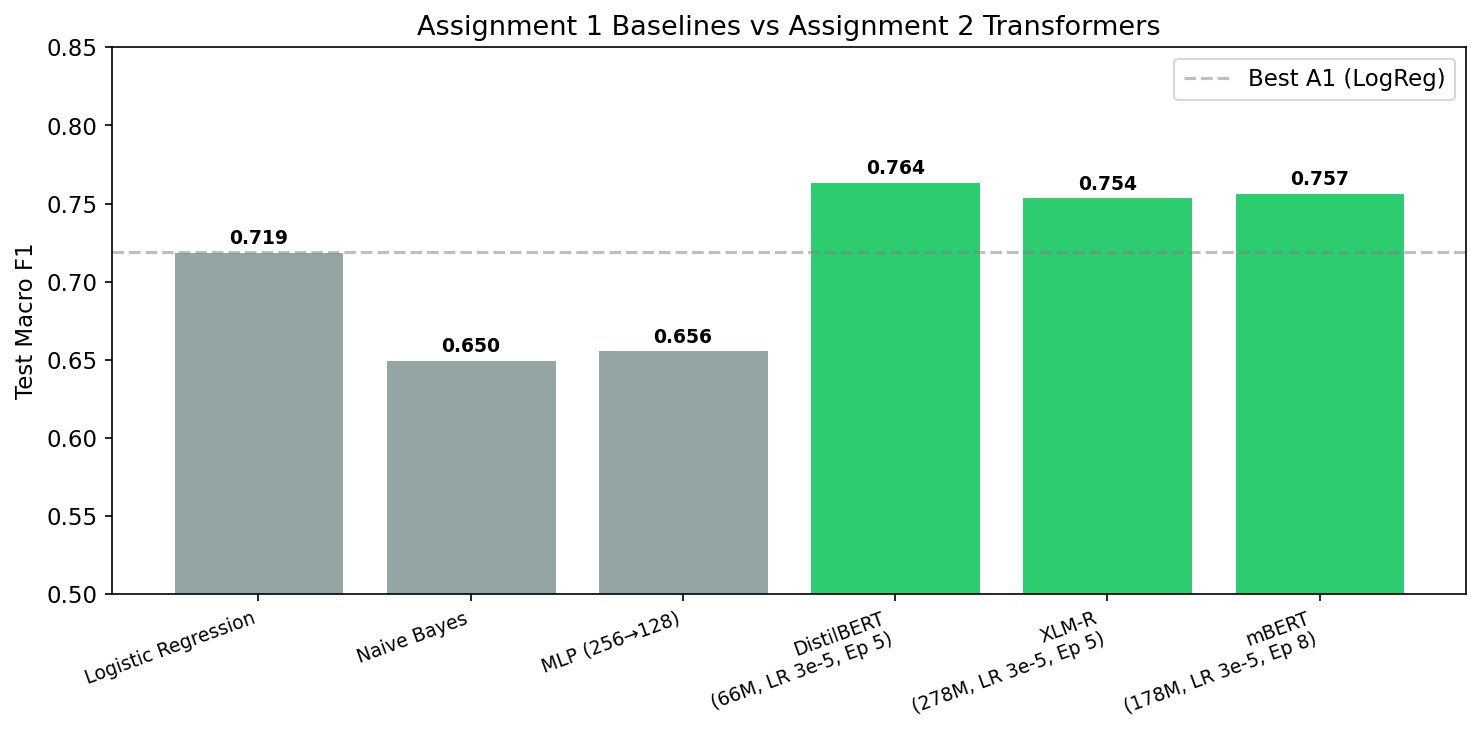

In [48]:
# Assignment 1 vs Assignment 2: Macro F1 comparison
# Gray = A1 baselines (TF-IDF), Green = A2 transformers (fine-tuned BERT)
display(Image("charts/02_a1_vs_a2_macro_f1.png"))

> **Finding:** Every transformer configuration outperforms every A1 baseline on macro F1. The best transformer (DistilBERT, 0.764) improves on the best baseline (Logistic Regression, 0.719) by +6.3%. The improvement is largest on the hardest class: `needs_reply` F1 improved from 0.43 → 0.54 (+24%).

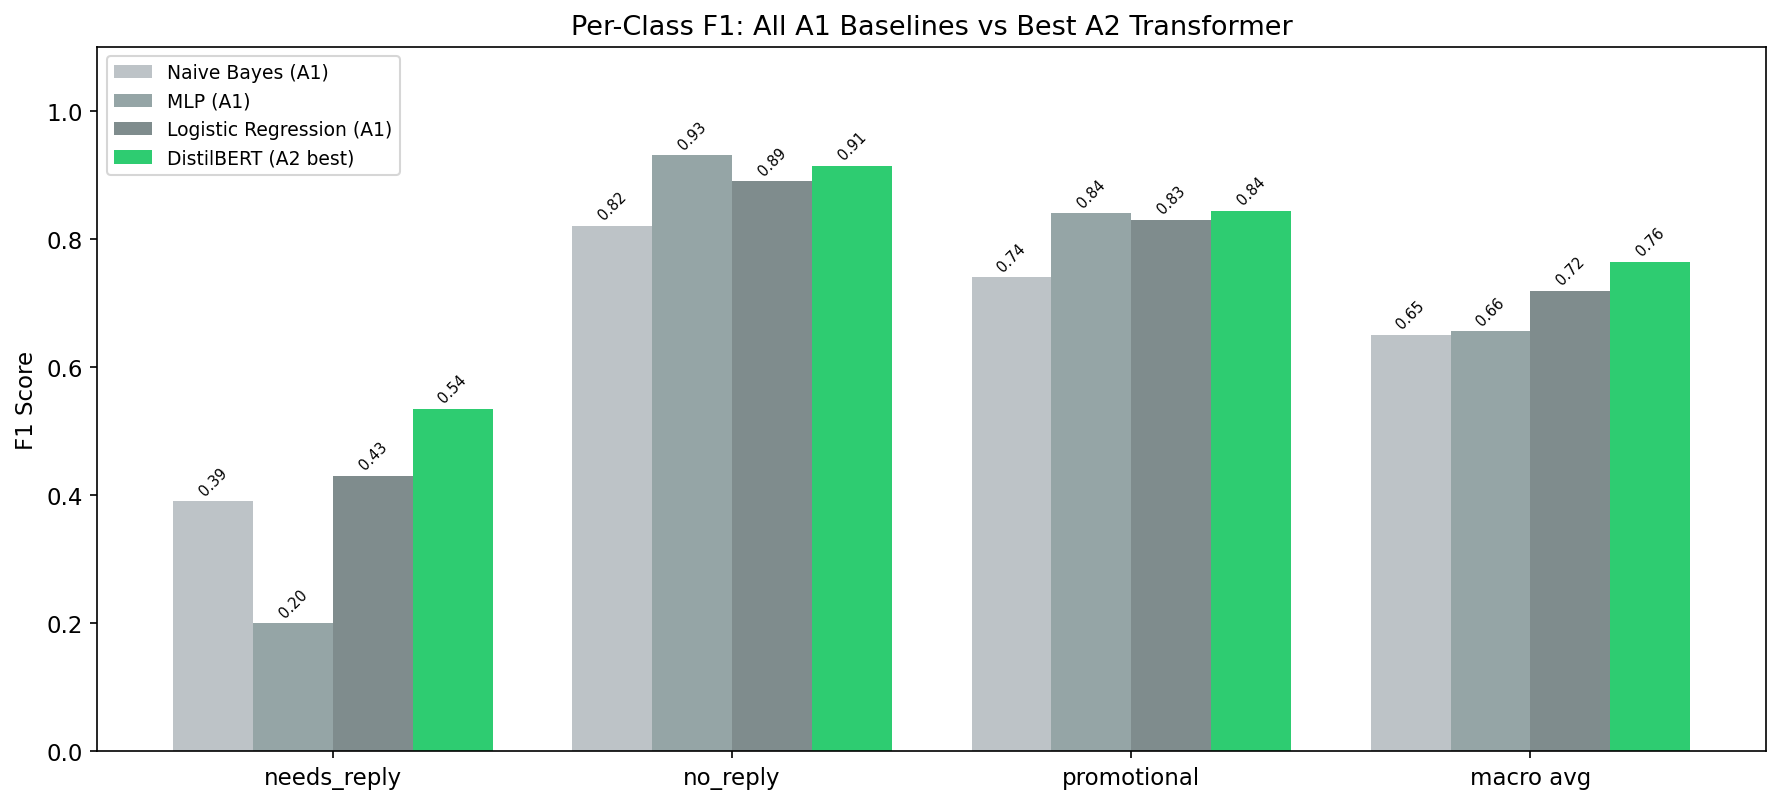

In [49]:
# Per-class F1 breakdown: all A1 baselines vs best transformer
# Key: needs_reply improvement (+24%) drives the macro F1 gain
display(Image("charts/03_per_class_f1_comparison.png"))

## Architecture comparison

The most surprising finding: **DistilBERT (66M* parameters) outperforms XLM-R (278M) and mBERT (178M)** despite being 3-4x smaller.

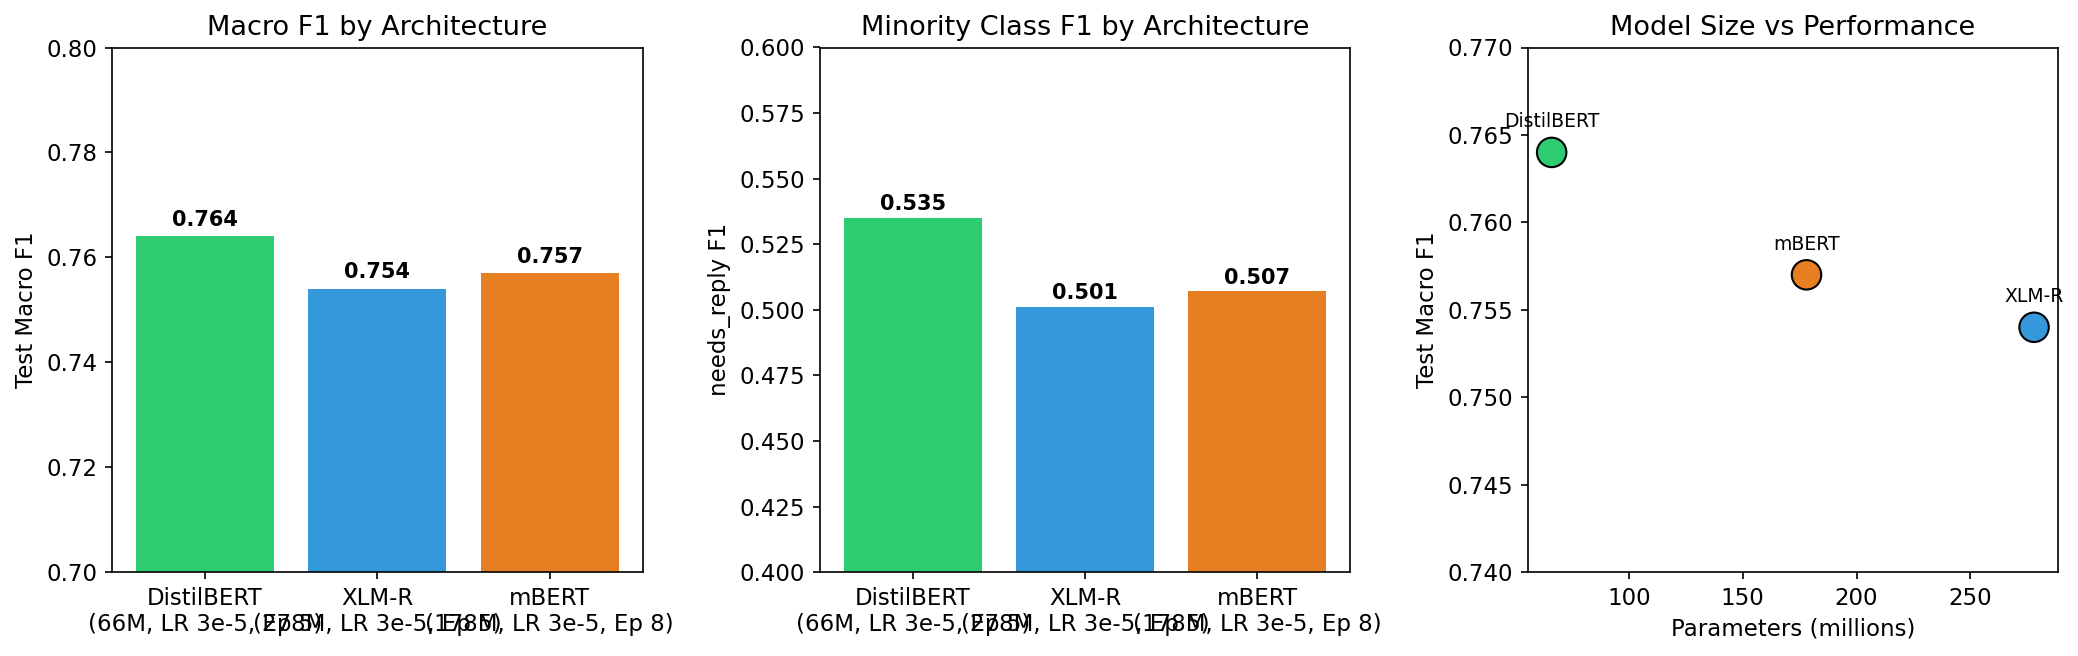

In [50]:
# Architecture comparison + model size vs performance
display(Image("charts/04_architecture_comparison.png"))

### Architecture comparison discussion

The performance differences between architectures are **small** — DistilBERT (0.764), mBERT (0.757), and XLM-R (0.754) are all within ~1% macro F1 of each other. All three are viable for this task.

That said, DistilBERT's consistent slight edge is noteworthy because it is the smallest model. Several factors may contribute:

- **Hyperparameter sensitivity differs by model size.** DistilBERT converged well across multiple learning rates (2e-5 to 5e-5), while XLM-R required more careful tuning — its best result used higher weight decay (0.1) and a specific learning rate. Larger models have more hyperparameters interacting, making the search space harder.
- **Training efficiency.** DistilBERT trains ~3x faster per epoch, which allowed us to explore more configurations in the same GPU budget. More experiments = better chance of finding a good configuration.
- **The task may not require deep representations.** Email triage relies heavily on surface cues (subject line patterns, sender type, reply-chain markers) that may be captured in fewer layers.

The practical takeaway: for this dataset size and task complexity, **model choice matters less than hyperparameter tuning** — the best DistilBERT config outperforms the worst by 3.4% (0.764 vs 0.740), while the architecture gap is only 1%.

## Confusion matrices

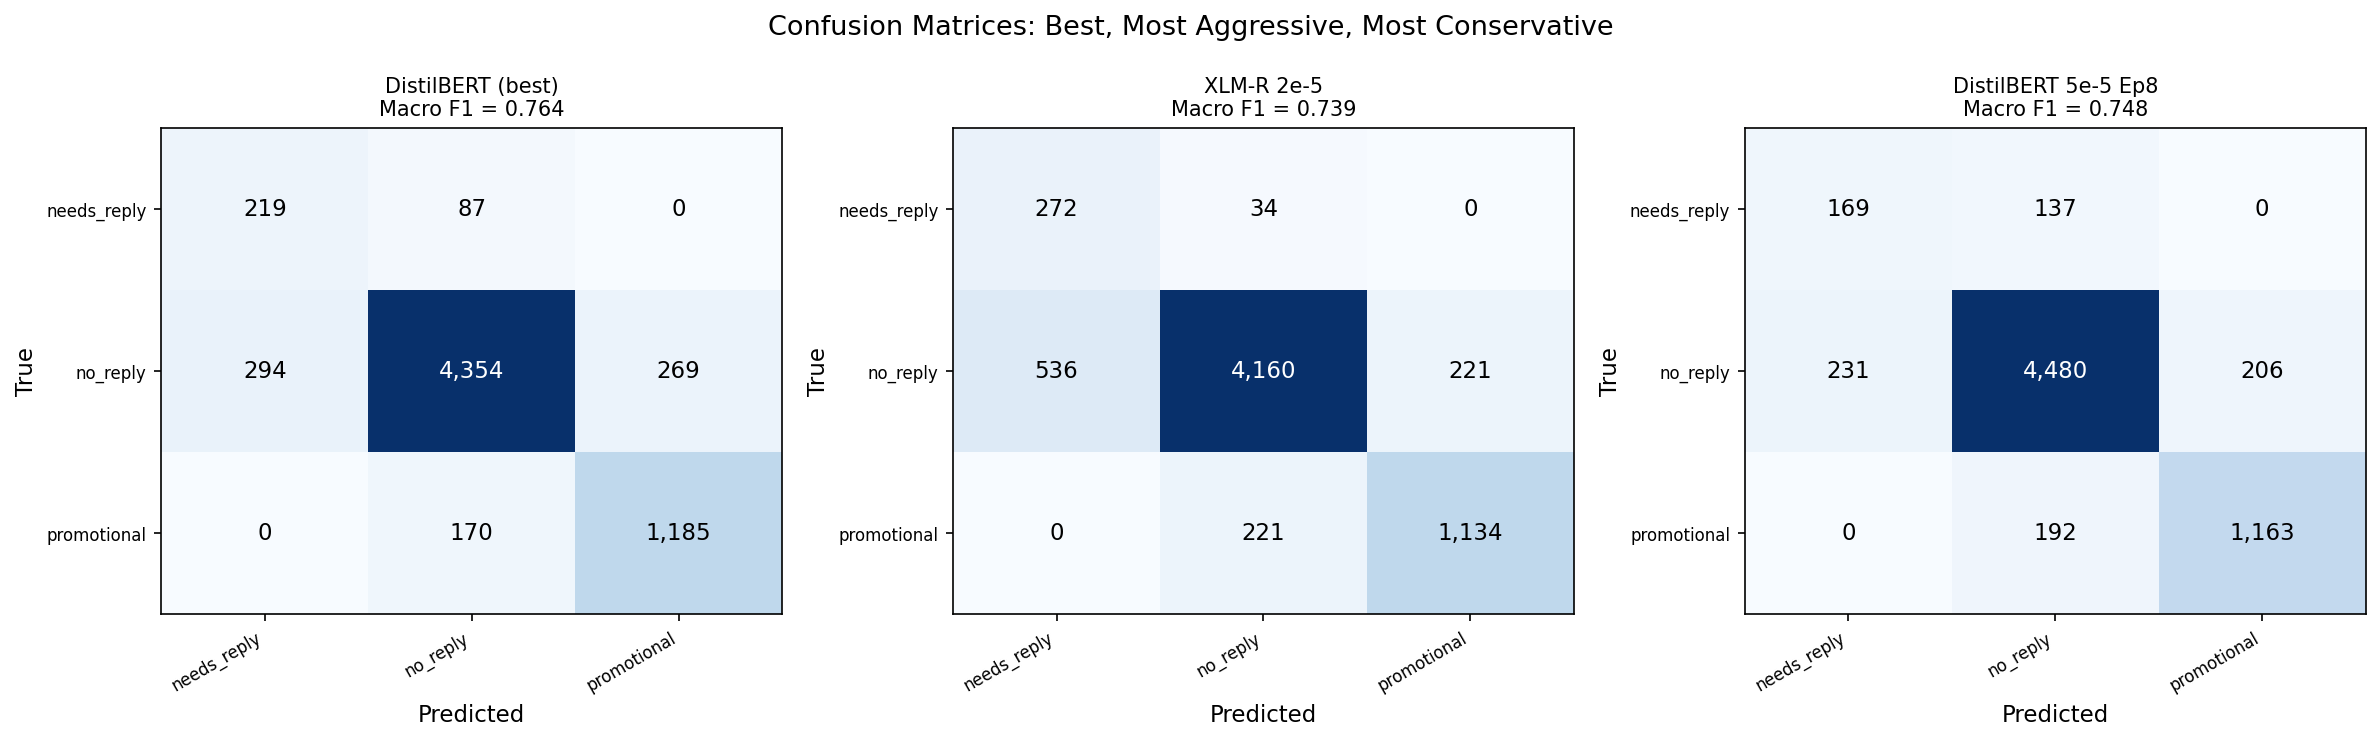

In [51]:
# Confusion matrices: best, most aggressive, most conservative
display(Image("charts/07_confusion_matrices.png"))

> **Finding:** The confusion matrices reveal a precision-recall spectrum. No model ever predicts `needs_reply` when the true label is `promotional` (bottom-left cell is always 0) — promotional emails are semantically distinct from personal correspondence. The hard boundary is between `needs_reply` and `no_reply`, where intent (not topic) determines the class.

The three confusion matrices reveal how different models handle the precision-recall tradeoff:

- **DistilBERT (best):** Balanced — catches 219/306 needs_reply emails (72%) with 294 false positives
- **XLM-R 2e-5 (aggressive):** Catches 272/306 needs_reply (89% recall!) but at the cost of 536 false positives — it flags too many normal emails
- **DistilBERT 5e-5 Ep8 (conservative):** Only catches 169/306 needs_reply (55%) but with just 231 false positives — it misses too many emails that need replies

**Key observation:** No model ever predicts `needs_reply` when the true label is `promotional` (bottom-left cell is always 0). This makes sense — promotional emails look nothing like personal correspondence needing a reply. The hard boundary is between `needs_reply` and `no_reply`, which are both personal emails differing only in intent.

## Precision-recall tradeoff across all models

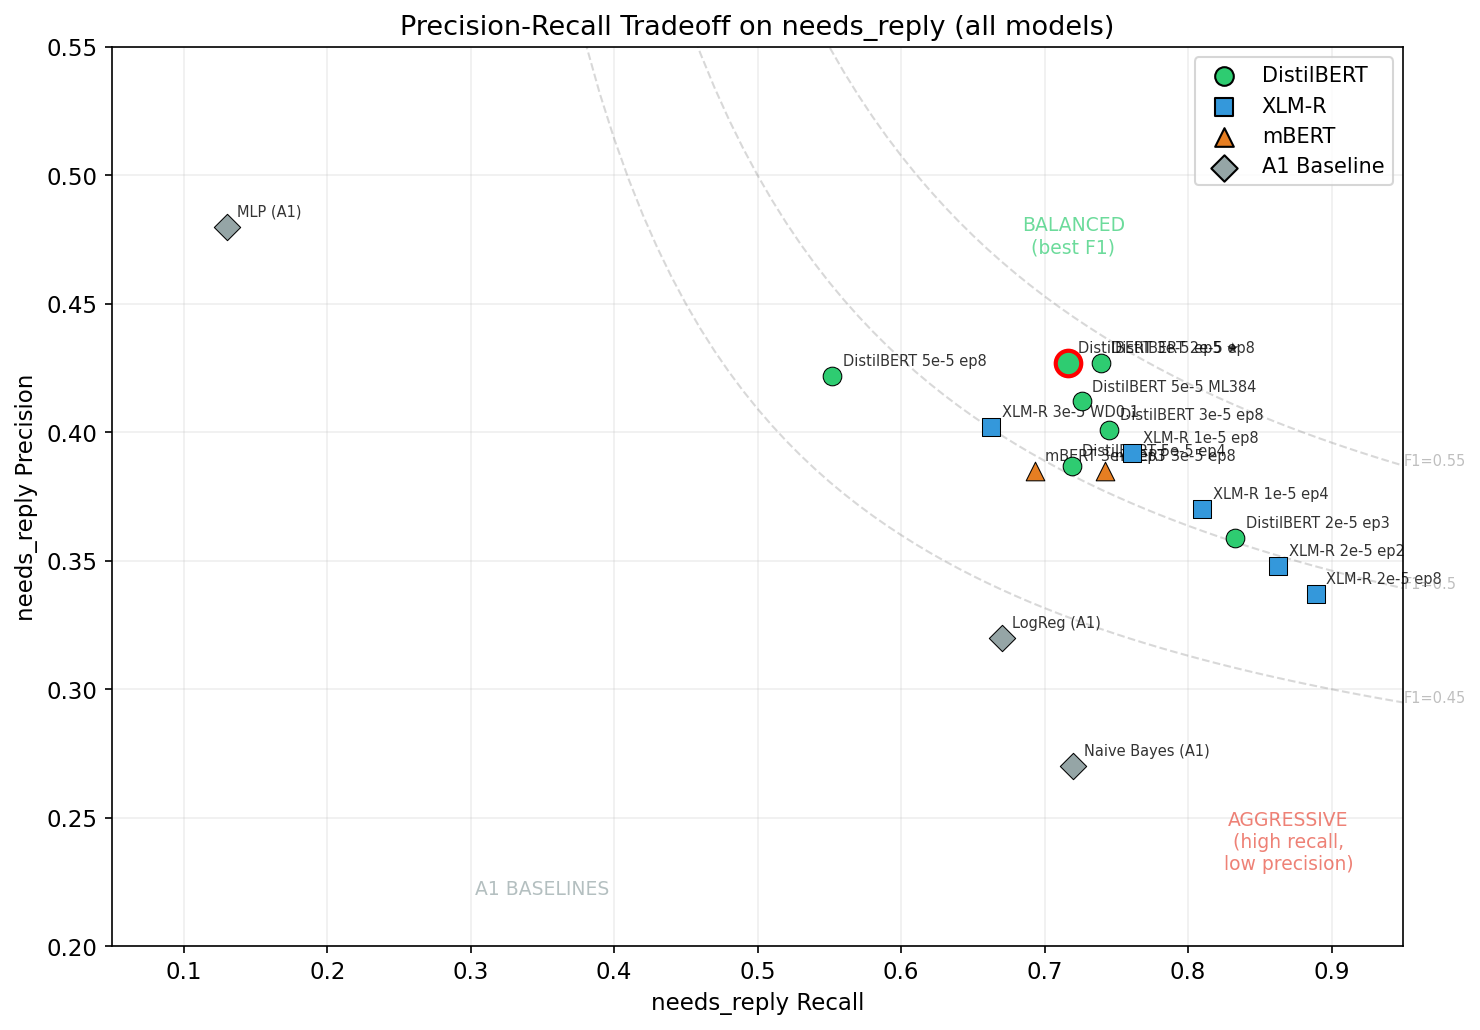

In [52]:
# Precision-recall scatter (all models including A1 baselines)
display(Image("charts/08_precision_recall_scatter.png"))

> **Finding:** Models naturally cluster by architecture — XLM-R models (blue) are aggressive (high recall, low precision), DistilBERT models (green) are balanced, and A1 baselines (gray) fall outside the transformer cluster entirely. The MLP is an extreme outlier with 48% precision but only 13% recall.

The precision-recall scatter reveals a continuous spectrum:

- **A1 baselines** (gray diamonds) cluster in the lower-left — MLP is an extreme outlier with 48% precision but only 13% recall (it almost never predicts `needs_reply`)
- **XLM-R models** (blue squares) cluster in the high-recall, low-precision region — they're aggressive, flagging almost everything as needs_reply
- **DistilBERT models** (green circles) spread across the balanced zone
- **The starred DistilBERT 3e-5 ep5** achieves the best F1 by balancing both axes

This tradeoff is practically meaningful: an email alert system that flags too many false positives (aggressive) becomes annoying and gets ignored; one that misses too many real needs_reply emails (conservative) defeats the purpose.

## Hyperparameter analysis

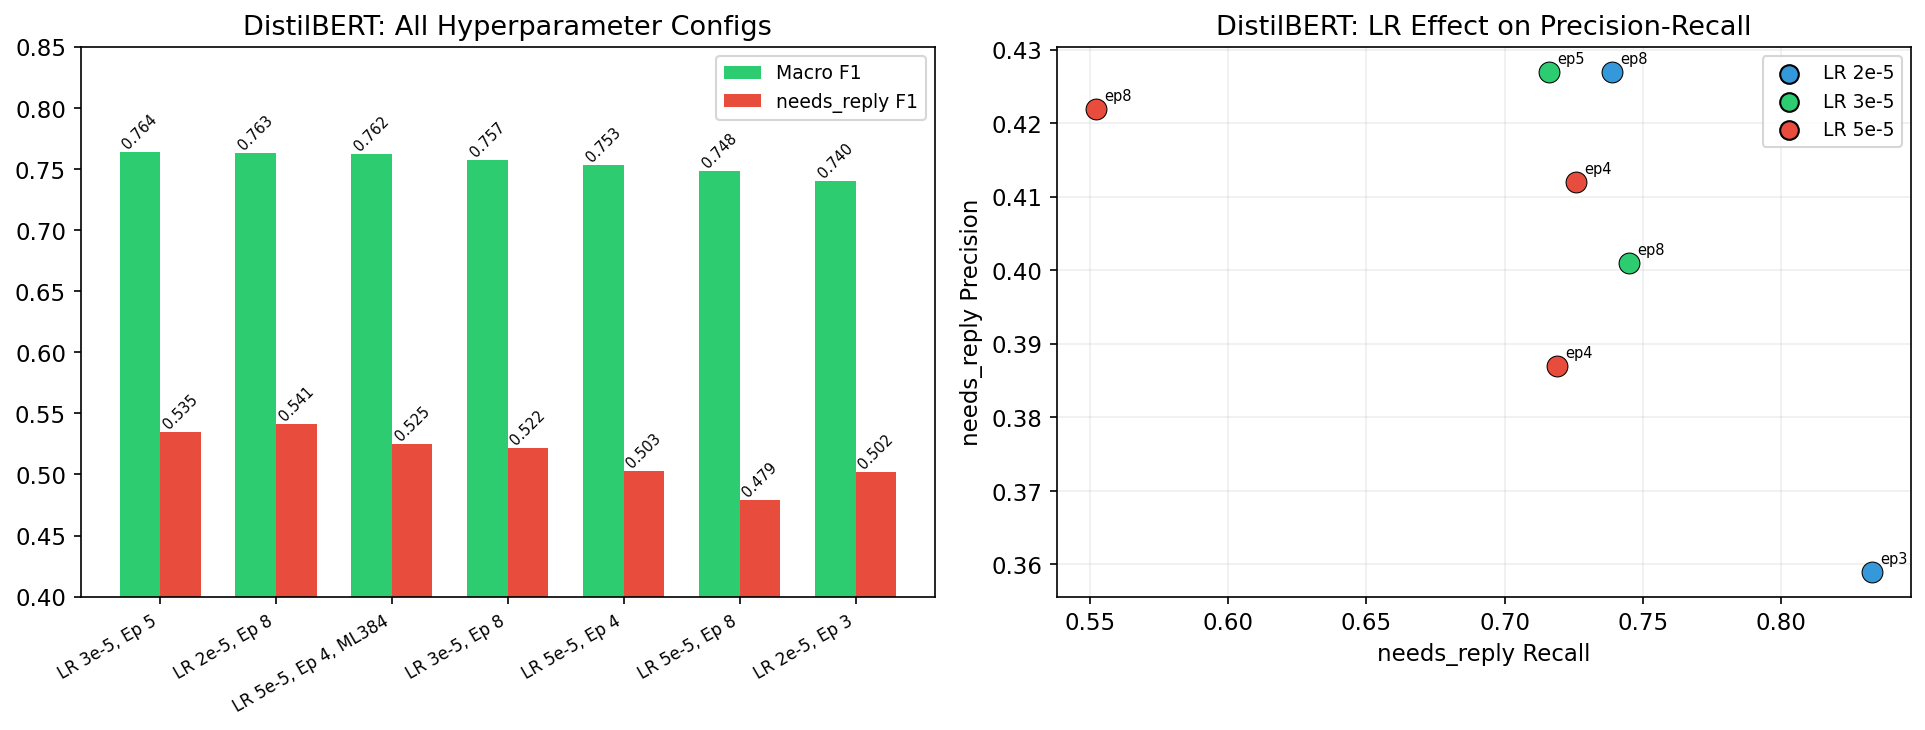

In [53]:
# DistilBERT hyperparameter analysis
display(Image("charts/10_distilbert_hyperparams.png"))

### Key hyperparameter findings

**Learning rate is the most impactful hyperparameter:**
- **LR 2e-5 (low):** Slow convergence, high recall (model predicts needs_reply liberally), needs more epochs
- **LR 3e-5 (sweet spot):** Best macro F1, balanced precision-recall
- **LR 5e-5 (high):** Fast convergence but overfits with many epochs, becomes conservative (low recall)

**Epochs:** DistilBERT 3e-5 peaked at epoch 5, then overfit. DistilBERT 5e-5 peaked at epoch 4. More training doesn't help — it hurts the minority class.

**Max sequence length (256 vs 384 vs 512):** No meaningful difference (0.764 vs 0.762 vs 0.763). The classification signal is in the subject line and first few sentences, not deep in the email body.

**Weight decay:** WD=0.1 helped XLM-R regularize (0.754 macro F1 vs 0.739 at WD=0.01) but didn't close the gap to DistilBERT.

---

# Section 8: Results Visualization & Conclusions

## Error analysis (best model: DistilBERT LR 3e-5, Ep 5)

Out of 6,578 test emails, the model correctly classified 5,758 (87.5%) and made 820 errors (12.5%).

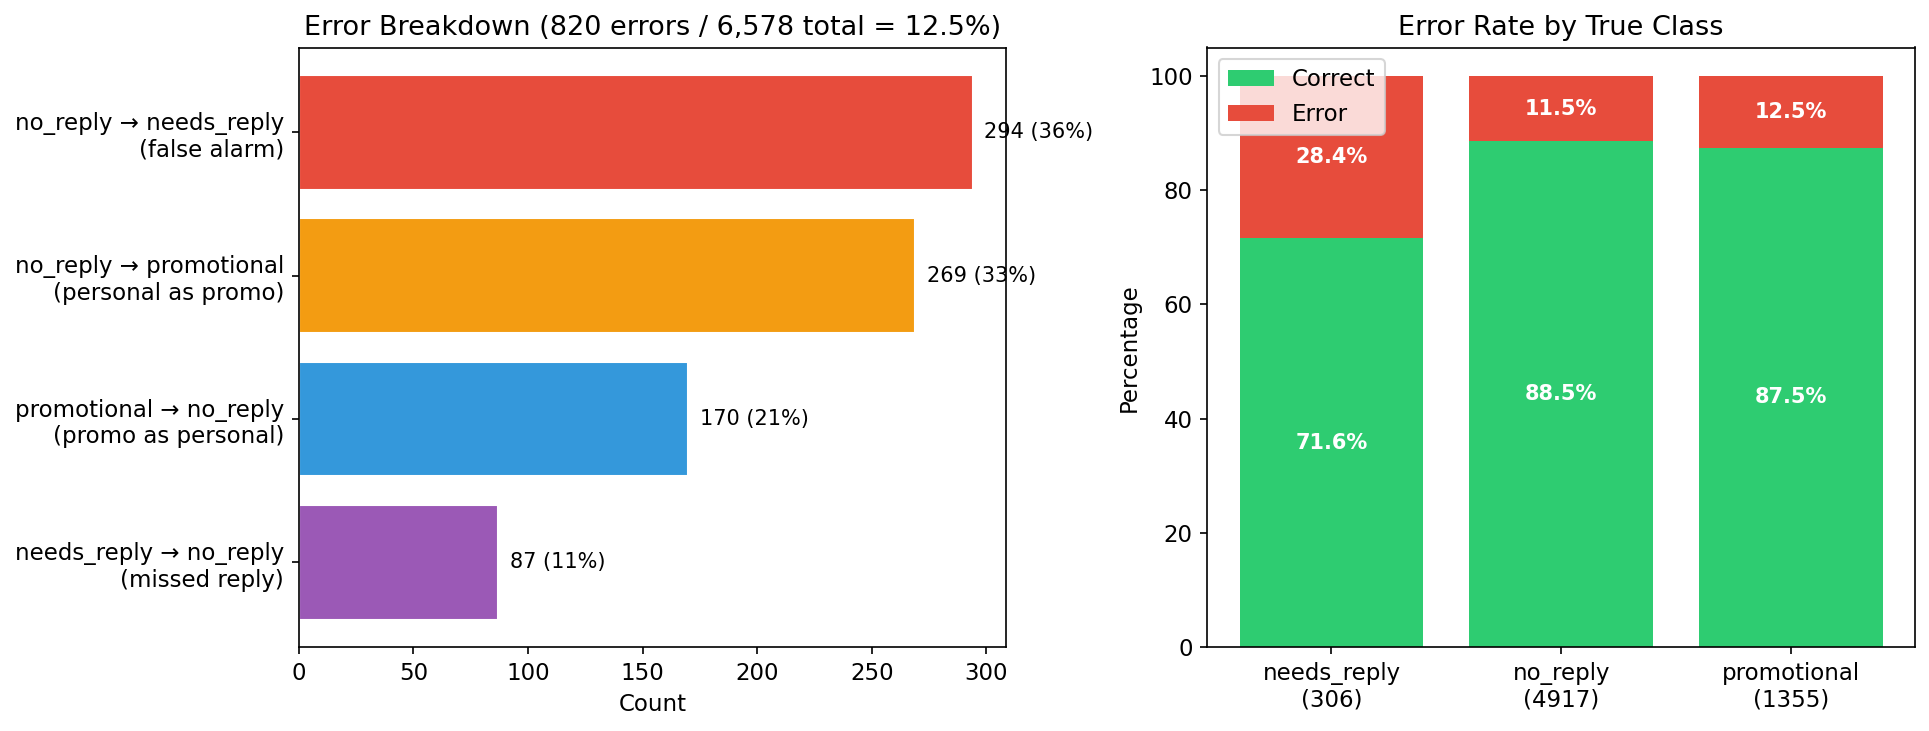

In [54]:
# Error analysis: 820 errors out of 6,578 test emails (12.5% error rate)
# Left: error type breakdown | Right: error rate by true class
display(Image("charts/09_error_analysis.png"))

### Error breakdown

| Error type | Count | % of errors | % of true class | Interpretation |
|-----------|-------|-------------|-----------------|---------------|
| no_reply → needs_reply | 294 | 35.9% | 6.0% of no_reply | "RE:", "Fwd:" patterns trigger false alarms |
| no_reply → promotional | 269 | 32.8% | 5.5% of no_reply | Polish marketing language in personal emails |
| promotional → no_reply | 170 | 20.7% | 12.5% of promotional | SaaS onboarding emails look like personal notifications |
| needs_reply → no_reply | 87 | 10.6% | 28.4% of needs_reply | Forwarded invoices/docs that need action |

**69% of errors** are on the no_reply ↔ promotional boundary — these are emails where even a human might hesitate. Only **11% of errors** are the most costly type (missed needs_reply emails).

### Sample misclassifications

**needs_reply → no_reply (missed — model failed to flag):**
- *"Re: Econverse x Freenow"* — business partnership email requiring action, but looks like a forwarded FYI
- *"Webexpenses & Econverse: Pricing Proposal"* — pricing document that needs review, but subject doesn't signal urgency
- *"Fwd: Faktura numer FV/43/07/2023"* — forwarded invoice requiring action

**no_reply → needs_reply (false alarm):**
- *"RE: Econverse Cup - zaproszenie do współpracy"* — old event invitation (already passed), but "RE:" prefix triggers the model
- *"Fwd: Faktury za Econverse Poznań"* — forwarded for reference only, not requiring action

**promotional → no_reply (promo slipped through):**
- *"Welcome to MURAL"*, *"Welcome to Fireflies"* — SaaS onboarding emails that look like personal account notifications
- *"Invite your teammates"* — call-to-action that resembles personal correspondence

**no_reply → promotional (personal misread as promo):**
- *"Zapisz się na webinary o podatkach 2023"* — Polish tax webinar invitation from a colleague, not a company
- *"Hubert, zostały tylko 2 dni – otrzymaj do 470 zł zwrotu!"* — personalized offer that uses marketing-style language

### Final retrain experiment

I attempted to improve the best model by retraining on train+val combined (26,205 samples vs 22,977), then evaluating on the unchanged test set. Results:

| Attempt | Epochs | Test Macro F1 | needs_reply F1 | Issue |
|---------|--------|---------------|----------------|-------|
| Sweep best (train only) | 5 | **0.764** | **0.535** | — |
| Retrain attempt 1 | 9 | 0.736 | 0.433 | Overfit — NR recall collapsed to 0.38 |
| Retrain attempt 2 | 4 | 0.755 | 0.518 | Better, but still worse than sweep best |

**Conclusion:** Without a validation set for checkpoint selection, the model overfits past its sweet spot. Proper model selection via validation matters more than having 14% extra training data. The sweep best (macro F1 = 0.764) remains the final model.

---

## Conclusions

1. **Transformers outperform all A1 baselines.** Best transformer (DistilBERT, macro F1 = 0.764) beats best A1 model (LogReg, 0.719) by +6.3%. The biggest gain is on the hardest class: `needs_reply` F1 improved from 0.43 → 0.54 (+24%).

2. **Smaller models win on limited data.** DistilBERT (66M* params) beats XLM-R (278M) and mBERT (178M). Knowledge distillation + implicit regularization from fewer parameters outweighs raw model capacity when training data is scarce.

3. **Class imbalance remains the bottleneck.** Despite weighted loss, `needs_reply` F1 of 0.54 is the ceiling across all configurations. The model catches 72% of emails needing replies but with 43% precision — meaning more than half its "needs_reply" predictions are false alarms.

4. **More training hurts the minority class.** A universal "conservative drift" pattern: all models' `needs_reply` recall drops from ~95% at epoch 1 to ~65% by epoch 8+, as the model learns to default to the safer majority prediction.

5. **Hyperparameter sensitivity is asymmetric.** Learning rate matters far more than batch size, max sequence length, or weight decay. The optimal LR (3e-5) is a narrow sweet spot — 2e-5 undertrains, 5e-5 overtains.

6. **The transformer improvement is meaningful but not overwhelming** — going from 0.719 to 0.764 required GPU training, transformer pretraining knowledge, and careful hyperparameter tuning. This highlights that the marginal gains from transformers must be weighed against computational cost for production deployment.

7. **The hardest errors are semantically ambiguous.** Misclassified emails involve genuine ambiguity (forwarded invoices, expired event invitations, SaaS onboarding that looks personal) — not random noise. This suggests a ceiling for any text-only approach without additional context like sender history or reply latency.

---

# Section 9: Executive Summary

## Pipeline overview

```
Gmail Takeout (.mbox × 2: Polish business + English student)
        │
        ▼
  Data Ingestion
  (MIME decode, HTML-first body extraction, metadata, thread IDs)
        │
        ▼
  Labeling
  trigger-based needs_reply │ no_reply │ promotional (Gmail labels)
  + automated sender filtering
        │
        ▼
  Thread-aware Group Split (70/10/20)
  train: 22,977 │ val: 3,228 │ test: 6,578
        │
    ┌───┴────────────────────────────┐
    ▼                                ▼
  A1 PIPELINE              A2 PIPELINE
  ┌─────────────────────┐          ┌──────────────────────────────┐
  │ Text Cleaning       │          │ Light normalization          │
  │ TF-IDF (5K features)│          │ "subject: ... body: ..."     │
  │ + 9 structural feat. │          │ Tokenize (max_len 256)       │
  │                     │          │                              │
  │ Models:             │          │ Models:                      │
  │ • Logistic Reg      │          │ • DistilBERT (66M*) ← BEST   │
  │ • Naive Bayes       │          │ • XLM-R (278M)               │
  │ • MLP (256→128)     │          │ • mBERT (178M)               │
  │                     │          │                              │
  │ 5-fold GroupKFold   │          │ Weighted CrossEntropy        │
  │ + GridSearchCV      │          │ AdamW + warmup               │
  │                     │          │ 15+ hyperparameter configs   │
  └─────────────────────┘          └──────────────────────────────┘
    │                                │
    └────────────┬───────────────────┘
                 ▼
          Test Set Evaluation (6,578 emails)
          Macro F1: A1 best = 0.719 → A2 best = 0.764 (+6.3%)
                 │
                 ▼
          Error Analysis, Confusion Matrices,
          Precision-Recall Tradeoff Analysis
```

## Summary

I built a pipeline that classifies ~33,000 incoming Gmail emails from my two accounts (Polish business + English student) into three categories: `needs_reply`, `no_reply`, and `promotional`. The goal is to build an intelligent email triage system.

**Assignment 1** established baselines using TF-IDF features with classical models. Logistic Regression won with a macro F1 of 0.719, but struggled with the rare `needs_reply` class (F1 = 0.43, catching only 67% of emails needing replies).

**Assignment 2** extended this by fine-tuning three pretrained multilingual transformer models — DistilBERT, XLM-RoBERTa, and mBERT — on the same classification task. I conducted a systematic hyperparameter search across 15+ configurations varying learning rate (1e-5 to 5e-5), epochs (2-12), batch size (16-128), max sequence length (256-512), and weight decay (0.01-0.1), using GPU training on Google Colab (NVIDIA A100).

**The best model was DistilBERT** (LR 3e-5, 5 epochs), achieving a macro F1 of **0.764** — a 6.3% improvement over the best A1 baseline. The biggest gain was on the hardest class: `needs_reply` F1 improved from 0.43 → 0.54 (+24%), meaning the transformer catches more emails that actually need my attention while making fewer false alarms.

The most surprising finding was that **DistilBERT (66M* parameters) outperformed models 3-4x its size** (XLM-R at 278M, mBERT at 178M). This demonstrates that on limited training data (~23K examples), a smaller model with good pretrained knowledge generalizes better than a larger model that overfits.

## Improvements over Assignment 1

| Area | Assignment 1 | Assignment 2 |
|------|-------------|-------------|
| Model comparison depth | 3 models, single metric focus | 15+ configs across 4 architectures, per-class metrics, confusion matrices, precision-recall analysis, hyperparameter sensitivity |
| Text representation | TF-IDF (bag-of-words, no semantics) | Fine-tuned multilingual transformers (DistilBERT, XLM-R, mBERT); also attempted mDeBERTa (OOM) |
| Problem clarity | Classification task defined but could be clearer | Explicit 3-class supervised triage with clear motivation; discussed why not topic modeling |
| Analysis depth | Basic classification reports | Error analysis with examples, overfitting dynamics, precision-recall tradeoff spectrum, architecture comparison |

## Shortcomings and possible improvements

1. **Class imbalance:** Even with weighted cross-entropy, `needs_reply` remains the bottleneck (F1 = 0.54). Techniques not explored: SMOTE oversampling, focal loss, threshold tuning on the decision boundary, or training with a larger pool of `needs_reply` examples from additional email accounts.

2. **No resampling strategies tested:** Random oversampling of the minority class or undersampling the majority class could change the precision-recall operating point in favor of `needs_reply` recall.

3. **Model calibration:** Validation loss increased while macro F1 improved, indicating poor calibration. Temperature scaling or Platt scaling could produce better-calibrated probability estimates.

4. **Richer features:** Sender history (do I usually reply to this person?), time-of-day patterns, and reply latency could add predictive power beyond text content alone.

5. **RNN/LSTM comparison:** A bidirectional LSTM with pretrained embeddings would provide an intermediate comparison point between classical bag-of-words models and full transformer fine-tuning, at lower computational cost.


---

# Section 10: References

## Models and frameworks

1. **Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K.** (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* NAACL-HLT 2019. https://arxiv.org/abs/1810.04805

2. **Sanh, V., Debut, L., Chaumond, J., & Wolf, T.** (2019). *DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter.* NeurIPS 2019 Workshop. https://arxiv.org/abs/1910.01108

3. **Conneau, A., et al.** (2020). *Unsupervised Cross-lingual Representation Learning at Scale.* ACL 2020. https://arxiv.org/abs/1911.02116 [XLM-RoBERTa]

4. **Vaswani, A., et al.** (2017). *Attention Is All You Need.* NeurIPS 2017. https://arxiv.org/abs/1706.03762 [Transformer architecture]

5. **Wolf, T., et al.** (2020). *Transformers: State-of-the-Art Natural Language Processing.* EMNLP 2020 (System Demonstrations). https://huggingface.co/transformers/

## Classical ML references (from A1)

6. **Pedregosa, F., et al.** (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12, pp. 2825–2830. https://scikit-learn.org/

7. **McKinney, W.** (2010). *Data Structures for Statistical Computing in Python.* SciPy 2010. https://pandas.pydata.org/

8. **Salton, G. & Buckley, C.** (1988). *Term-weighting approaches in automatic text retrieval.* Information Processing & Management, 24(5), pp. 513–523. [TF-IDF]

9. **Manning, C. D., Raghavan, P., & Schütze, H.** (2008). *Introduction to Information Retrieval.* Cambridge University Press. Chapter 13. [Multinomial Naive Bayes]

10. **Kingma, D. P. & Ba, J.** (2015). *Adam: A Method for Stochastic Optimization.* ICLR 2015. https://arxiv.org/abs/1412.6980

## Tools and data

11. **Google Takeout** — https://takeout.google.com/ [Email export]

12. **BeautifulSoup** — Richardson, L. *Beautiful Soup Documentation.* https://www.crummy.com/software/BeautifulSoup/

13. **Python `mailbox` module** — https://docs.python.org/3/library/mailbox.html

14. **Google Colab** — https://colab.research.google.com/ [GPU training infrastructure, NVIDIA A100]

15. **Loshchilov, I. & Hutter, F.** (2019). *Decoupled Weight Decay Regularization.* ICLR 2019. https://arxiv.org/abs/1711.05101 [AdamW optimizer]

---

*Supplementary code and GPU training notebooks available at: https://github.com/hubertpysklo/cs-156-ml*